# ARTI403 — Image Processing · Lab 2 — Solutions
### Digital Image Fundamentals — Sampling, Quantization, Arithmetic and Set Operations

In [1]:
%matplotlib inline
import os
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
matplotlib.rcParams['figure.dpi'] = 72

# Build the images/ folder from scikit-image sample data
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize as sk_resize
from skimage.util import img_as_ubyte
import imageio.v3 as iio

os.makedirs("images", exist_ok=True)
iio.imwrite("images/cameraman.tif", data.camera())
iio.imwrite("images/lena_gray_256.tif",
            img_as_ubyte(sk_resize(rgb2gray(data.astronaut()), (256, 256), anti_aliasing=True)))

# A.png and B.png : two overlapping binary sets for the logical / set operations
yy, xx = np.mgrid[0:256, 0:256]
A = np.where((xx - 100)**2 + (yy - 128)**2 <= 70**2, 255, 0).astype(np.uint8)   # filled circle
B = np.zeros((256, 256), dtype=np.uint8)
B[70:190, 130:240] = 255                                                        # filled square
iio.imwrite("images/A.png", A)
iio.imwrite("images/B.png", B)

print(sorted(os.listdir("images")))

['A.png', 'B.png', 'cameraman.tif', 'coffee.png', 'lena_gray_256.tif']


## 1 — Image Sampling and Quantization

### Step #1: Import the libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step #2: Define Functions

In [3]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                               interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

### Step #3: Import the image and set the parameters

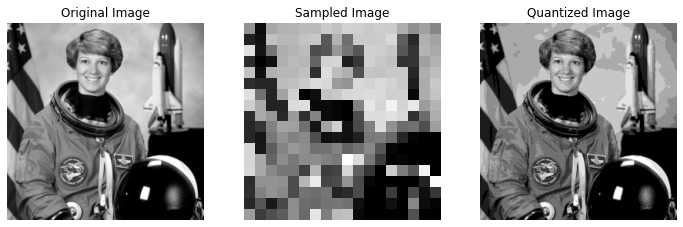

original : (256, 256) | unique gray levels: 255
sampled  : (18, 18) (256 // 14 = 18)
quantized: (256, 256) | unique gray levels: 10


In [4]:
image_path = 'images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

print("original :", original_image.shape, "| unique gray levels:", len(np.unique(original_image)))
print("sampled  :", sampled_image.shape, f"(256 // {sampling_factor} = {256 // sampling_factor})")
print("quantized:", quantized_image.shape, "| unique gray levels:", len(np.unique(quantized_image)))

Two notes on the output above:

1. **The sampled image only *looks* the same size** because Matplotlib stretches every subplot to fill its axes. It is really 18×18 pixels. To see the true effect of sampling, upsample it back to 256×256 with nearest-neighbour — done in Task #1.
2. `quantize_image` with `levels=9` does **not** give 9 levels. `256 // 9 = 28`, and `floor(255/28)*28 = 252`, so the output takes values `0, 28, 56, …, 252` — that is **10** levels. The integer division only lands exactly when `levels` is a power of 2. Verified below.

In [5]:
print("step size 256 //", quantization_levels, "=", 256 // quantization_levels)
print("actual output levels:", np.unique(quantize_image(original_image, 9)))
print("count:", len(np.unique(quantize_image(original_image, 9))), "(asked for 9)")

print("\npowers of 2 behave exactly:")
for L in [2, 4, 8, 16, 32]:
    print(f"  levels={L:>3} -> {len(np.unique(quantize_image(original_image, L))):>3} actual levels")

step size 256 // 9 = 28
actual output levels: [  0  28  56  84 112 140 168 196 224 252]
count: 10 (asked for 9)

powers of 2 behave exactly:
  levels=  2 ->   2 actual levels
  levels=  4 ->   4 actual levels
  levels=  8 ->   8 actual levels
  levels= 16 ->  16 actual levels
  levels= 32 ->  32 actual levels


## 2 — Arithmetic Operations

`resultImage.show()` opens an external system viewer, which does nothing inside a notebook — `display()` is used instead so the result appears inline.

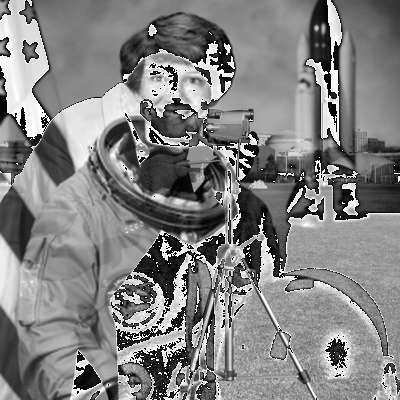

In [6]:
from PIL import Image

img1 = Image.open('images/lena_gray_256.tif')
img2 = Image.open('images/cameraman.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition)
display(resultImage)

The speckled black patches are **`uint8` overflow**: wherever `im1arr + im2arr` exceeds 255 the value wraps around modulo 256, so a very bright sum becomes very dark. Two correct alternatives:

* `cv2.add` — **saturating** addition, clips at 255
* averaging or weighted blending — `(A + B) / 2`, keeps the result in range

pixels where the true sum exceeds 255: 43.7% of the image


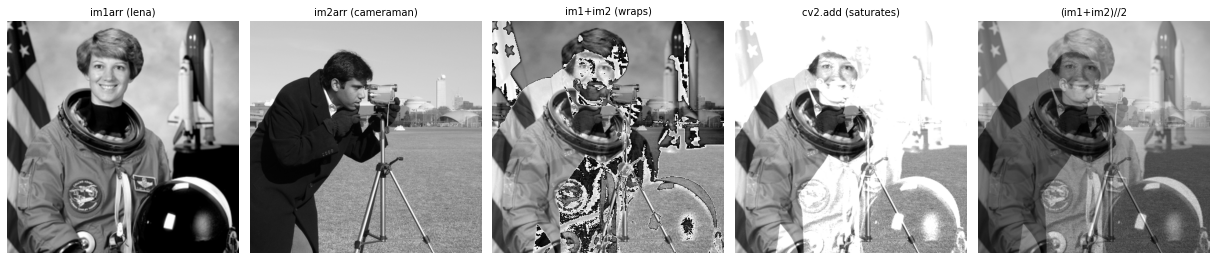

In [7]:
wrapped   = im1arr + im2arr                                    # uint8 wrap-around
saturated = cv2.add(im1arr, im2arr)                            # clipped at 255
averaged  = ((im1arr.astype(np.uint16) + im2arr) // 2).astype(np.uint8)
blended   = cv2.addWeighted(im1arr, 0.5, im2arr, 0.5, 0)

print("pixels where the true sum exceeds 255:",
      f"{(im1arr.astype(int) + im2arr > 255).mean()*100:.1f}% of the image")

fig, ax = plt.subplots(1, 5, figsize=(17, 3.8))
for a, (t, arr) in zip(ax, [("im1arr (lena)", im1arr), ("im2arr (cameraman)", im2arr),
                            ("im1+im2 (wraps)", wrapped), ("cv2.add (saturates)", saturated),
                            ("(im1+im2)//2", averaged)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

## 3 — Sets and Logical Operations

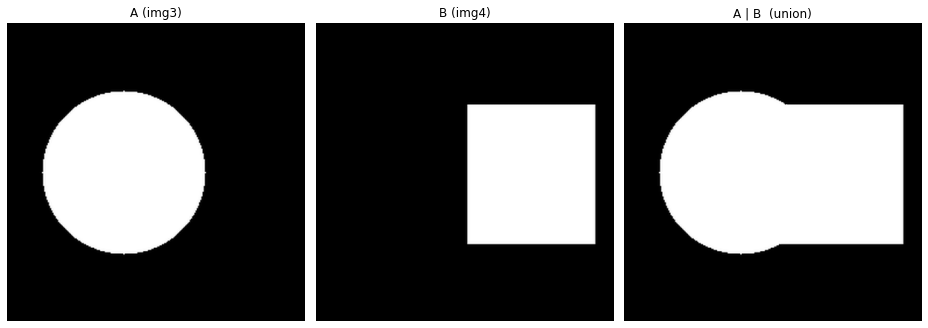

A white pixels: 35996
B white pixels: 30390
union white   : 58557


In [8]:
img3 = Image.open('images/A.png')
img4 = Image.open('images/B.png')

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
for a, (t, arr) in zip(ax, [("A (img3)", im3arr), ("B (img4)", im4arr), ("A | B  (union)", union)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

print("A white pixels:", (im3arr == 255).sum())
print("B white pixels:", (im4arr == 255).sum())
print("union white   :", (union == 255).sum())

## Task #1 — Change the sampling and quantization parameters and observe the effects

### 1.1 Sampling — spatial resolution
Each sampled image is upsampled back to 256×256 with nearest-neighbour so the **real** loss of detail is visible instead of being hidden by Matplotlib's rescaling.

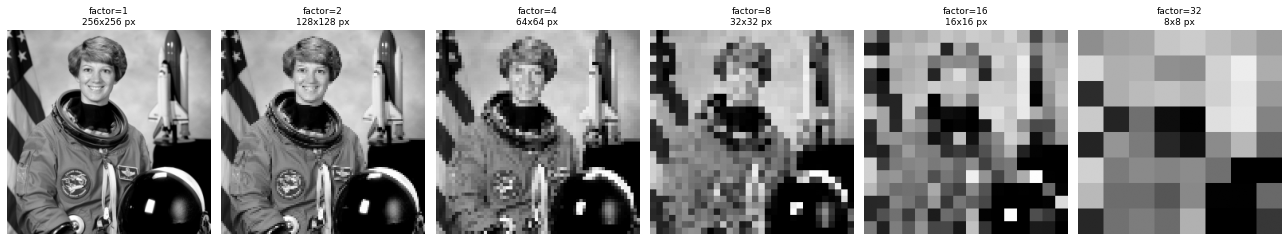

 factor         size     pixels      bytes
      1   (256, 256)     65,536     65,536
      2   (128, 128)     16,384     16,384
      4     (64, 64)      4,096      4,096
      8     (32, 32)      1,024      1,024
     16     (16, 16)        256        256
     32       (8, 8)         64         64


In [9]:
factors = [1, 2, 4, 8, 16, 32]

fig, ax = plt.subplots(1, len(factors), figsize=(18, 3.6))
for a, f in zip(ax, factors):
    s = sample_image(original_image, f)
    shown = cv2.resize(s, (256, 256), interpolation=cv2.INTER_NEAREST)   # upsample for display
    a.imshow(shown, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"factor={f}\n{s.shape[1]}x{s.shape[0]} px", fontsize=9)
    a.axis('off')
plt.tight_layout(); plt.show()

print(f"{'factor':>7} {'size':>12} {'pixels':>10} {'bytes':>10}")
for f in factors:
    s = sample_image(original_image, f)
    print(f"{f:>7} {str(s.shape):>12} {s.size:>10,} {s.nbytes:>10,}")

**Effect of sampling:** reducing spatial resolution destroys fine detail first (facial features, texture), then edges become visibly blocky — the classic **checkerboard / pixelation** artifact. Storage falls with the *square* of the factor: factor 4 keeps only 1/16 of the pixels.

### 1.2 Quantization — intensity resolution
Powers of two are used so the requested level count is exact.

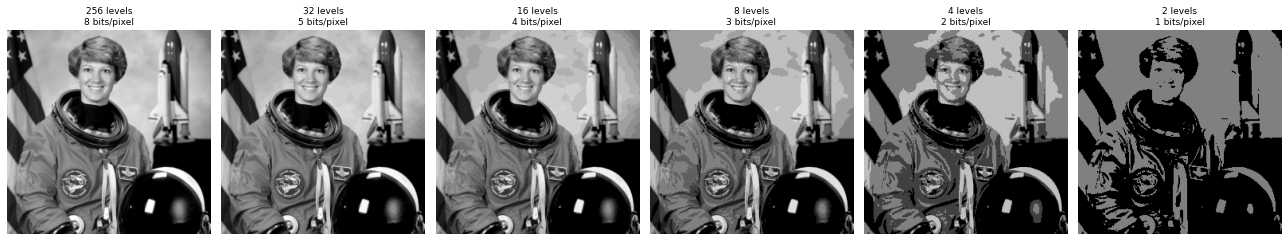

 levels  bits/px   actual   step
    256        8      255      1
     32        5       32      8
     16        4       16     16
      8        3        8     32
      4        2        4     64
      2        1        2    128


In [10]:
levels_list = [256, 32, 16, 8, 4, 2]

fig, ax = plt.subplots(1, len(levels_list), figsize=(18, 3.6))
for a, L in zip(ax, levels_list):
    q = quantize_image(original_image, L)
    a.imshow(q, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"{L} levels\n{int(np.log2(L))} bits/pixel", fontsize=9)
    a.axis('off')
plt.tight_layout(); plt.show()

print(f"{'levels':>7} {'bits/px':>8} {'actual':>8} {'step':>6}")
for L in levels_list:
    q = quantize_image(original_image, L)
    print(f"{L:>7} {int(np.log2(L)):>8} {len(np.unique(q)):>8} {256 // L:>6}")

**Effect of quantization:** spatial detail is untouched — the image stays 256×256 — but smooth intensity gradients break into visible bands. This is **false contouring**, and it becomes obvious below about 16 levels (4 bits). At 2 levels the image is pure binary.

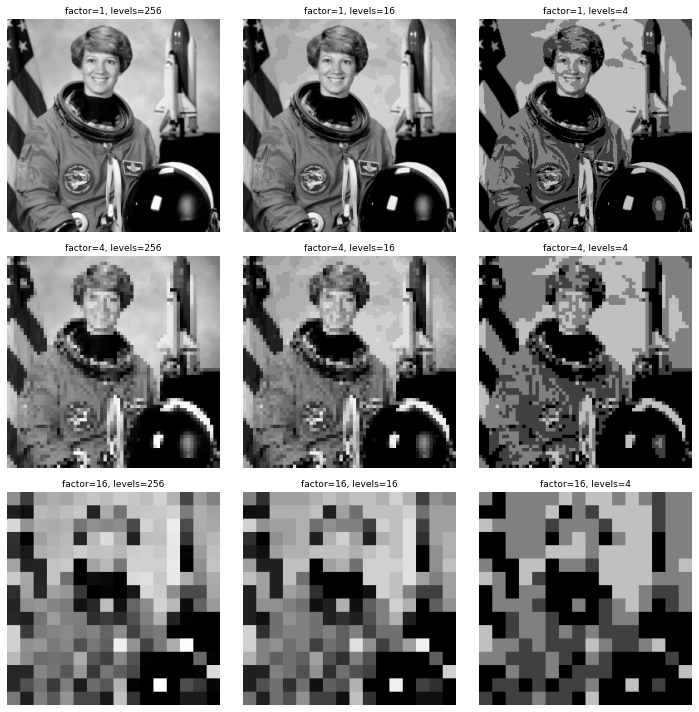

In [11]:
# Both degradations at once
fig, ax = plt.subplots(3, 3, figsize=(10, 10))
for i, f in enumerate([1, 4, 16]):
    for j, L in enumerate([256, 16, 4]):
        s = sample_image(original_image, f)
        q = quantize_image(s, L)
        shown = cv2.resize(q, (256, 256), interpolation=cv2.INTER_NEAREST)
        ax[i, j].imshow(shown, cmap='gray', vmin=0, vmax=255)
        ax[i, j].set_title(f"factor={f}, levels={L}", fontsize=9)
        ax[i, j].axis('off')
plt.tight_layout(); plt.show()

## Task #2 — Read two images, convert them into arrays, and perform the following operations

`im1arr` (lena) and `im2arr` (cameraman) are the two grayscale arrays, both 400×400.

In [12]:
print("im1arr:", im1arr.shape, im1arr.dtype, "| im2arr:", im2arr.shape, im2arr.dtype)

im1arr: (400, 400) uint8 | im2arr: (400, 400) uint8


### (1) Subtract two images and display the result

`im1arr - im2arr` in `uint8` **underflows**: a negative result wraps to a large positive number. The correct forms are `cv2.subtract` (clips at 0) or the **absolute difference**, which is what is normally wanted when comparing two images.

pixels where im1 < im2 (would go negative): 58.9%


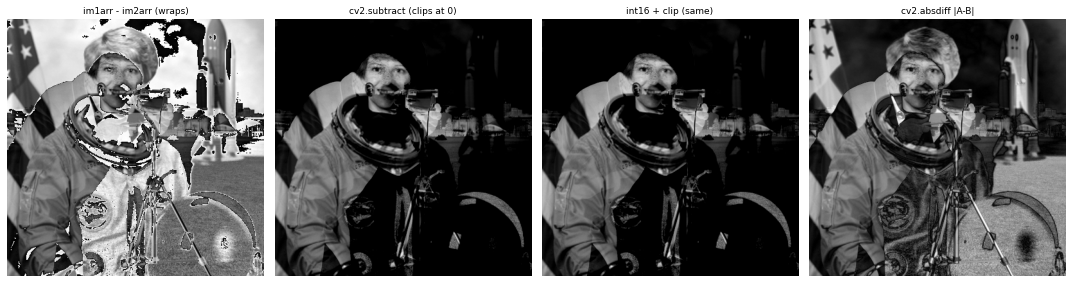

In [13]:
sub_wrap  = im1arr - im2arr                                                  # WRONG: underflows
sub_clip  = cv2.subtract(im1arr, im2arr)                                     # clipped at 0
sub_abs   = cv2.absdiff(im1arr, im2arr)                                      # |A - B|
sub_int   = np.clip(im1arr.astype(np.int16) - im2arr, 0, 255).astype(np.uint8)

print("pixels where im1 < im2 (would go negative):",
      f"{(im1arr.astype(int) < im2arr.astype(int)).mean()*100:.1f}%")

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr) in zip(ax, [("im1arr - im2arr (wraps)", sub_wrap),
                            ("cv2.subtract (clips at 0)", sub_clip),
                            ("int16 + clip (same)", sub_int),
                            ("cv2.absdiff |A-B|", sub_abs)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

### (2) Add one image with a constant value of 175 and display it

pixels that exceed 255 after +175: 65.1%
saturated result range: 175 - 255


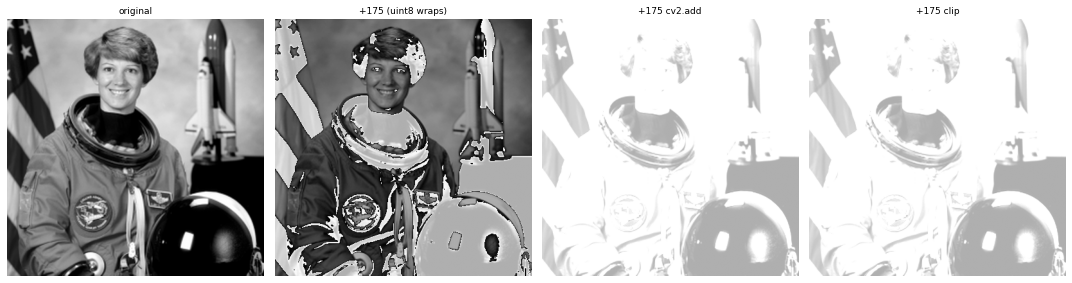

In [14]:
const = 175
add_wrap = im1arr + np.uint8(const)                                              # WRONG: wraps
add_sat  = cv2.add(im1arr, np.full_like(im1arr, const))                          # saturates at 255
add_clip = np.clip(im1arr.astype(np.int16) + const, 0, 255).astype(np.uint8)     # same, in NumPy

print(f"pixels that exceed 255 after +{const}:",
      f"{(im1arr.astype(int) + const > 255).mean()*100:.1f}%")
print("saturated result range:", add_sat.min(), "-", add_sat.max())

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr) in zip(ax, [("original", im1arr), (f"+{const} (uint8 wraps)", add_wrap),
                            (f"+{const} cv2.add", add_sat), (f"+{const} clip", add_clip)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

### Set operations on grayscale images — the definitions used

For binary sets the operations are bitwise. Extended to grayscale, where a pixel's value is its **degree of membership**, the standard definitions are:

| Operation | Binary | Grayscale |
|---|---|---|
| Complement $A^c$ | `~A` | `255 - A` |
| Union $A \cup B$ | `A \| B` | `np.maximum(A, B)` |
| Intersection $A \cap B$ | `A & B` | `np.minimum(A, B)` |
| Difference $A - B = A \cap B^c$ | `A & ~B` | `np.minimum(A, 255 - B)` |
| Symmetric difference $(A-B) \cup (B-A)$ | `A ^ B` | `np.maximum(A-B, B-A)` |

Each of the three tasks below is shown **both ways**: on the binary sets `A.png` / `B.png`, where the geometry is easy to verify, and on the two grayscale images as the task asks.

### (3) Set difference on two Gray-Scale images

binary: bitwise and min/max formulations agree? False


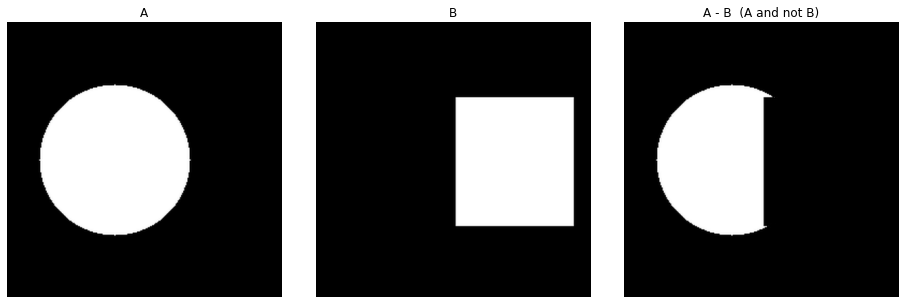

In [15]:
# --- binary sets, for verification ---
bin_diff_bitwise = im3arr & ~im4arr
bin_diff_minmax  = np.minimum(im3arr, 255 - im4arr)
print("binary: bitwise and min/max formulations agree?",
      np.array_equal(bin_diff_bitwise, bin_diff_minmax))

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (t, arr) in zip(ax, [("A", im3arr), ("B", im4arr), ("A - B  (A and not B)", bin_diff_bitwise)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

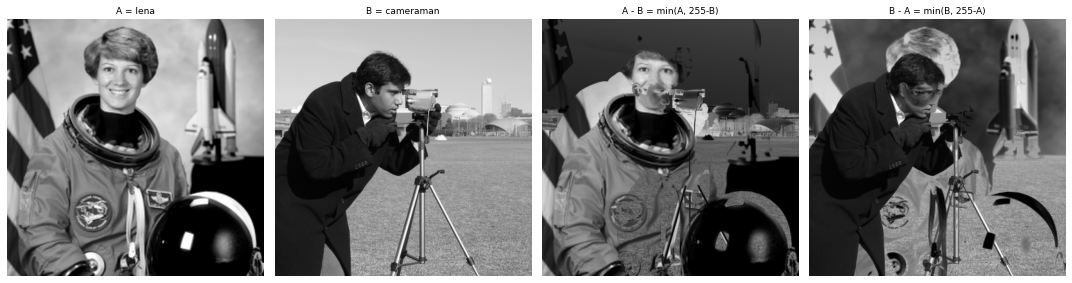

set difference is NOT commutative: False


In [16]:
# --- grayscale ---
diff_AB = np.minimum(im1arr, 255 - im2arr)     # A - B
diff_BA = np.minimum(im2arr, 255 - im1arr)     # B - A

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr) in zip(ax, [("A = lena", im1arr), ("B = cameraman", im2arr),
                            ("A - B = min(A, 255-B)", diff_AB),
                            ("B - A = min(B, 255-A)", diff_BA)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

print("set difference is NOT commutative:", np.array_equal(diff_AB, diff_BA))

### (4) Symmetric difference on two Gray-Scale images

binary: XOR and min/max formulations agree? False


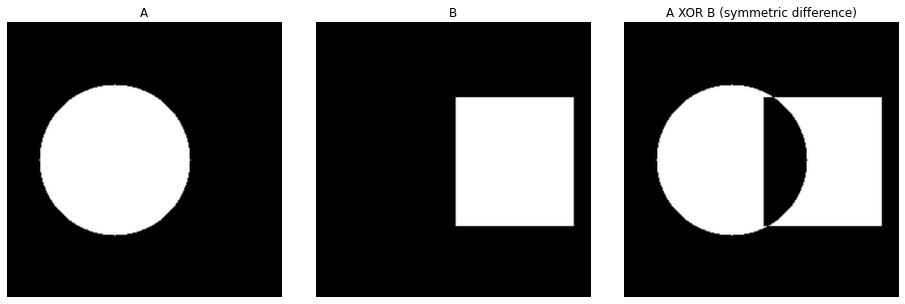

In [17]:
# --- binary sets ---
bin_sym_xor    = im3arr ^ im4arr
bin_sym_minmax = np.maximum(np.minimum(im3arr, 255 - im4arr),
                            np.minimum(im4arr, 255 - im3arr))
print("binary: XOR and min/max formulations agree?", np.array_equal(bin_sym_xor, bin_sym_minmax))

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (t, arr) in zip(ax, [("A", im3arr), ("B", im4arr), ("A XOR B (symmetric difference)", bin_sym_xor)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

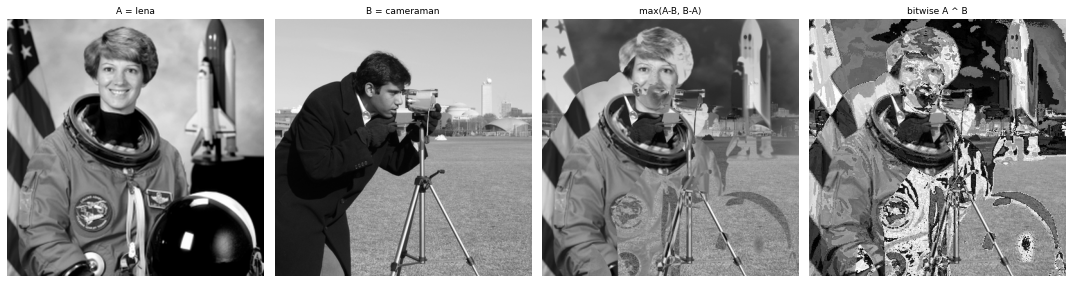

symmetric difference IS commutative: True


In [18]:
# --- grayscale ---
sym_diff = np.maximum(diff_AB, diff_BA)        # (A-B) union (B-A)
sym_xor  = im1arr ^ im2arr                     # bitwise version, for comparison

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr) in zip(ax, [("A = lena", im1arr), ("B = cameraman", im2arr),
                            ("max(A-B, B-A)", sym_diff), ("bitwise A ^ B", sym_xor)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

print("symmetric difference IS commutative:",
      np.array_equal(sym_diff, np.maximum(diff_BA, diff_AB)))

### (5) Intersection operations on two Gray-Scale images

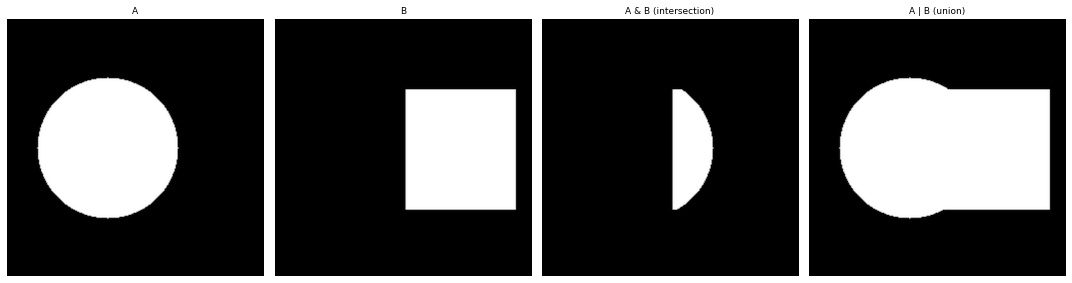

overlap pixels: 7839
check |A| + |B| = |A∪B| + |A∩B| : 66386 == 66396


In [19]:
# --- binary sets ---
bin_inter = im3arr & im4arr
bin_union = im3arr | im4arr

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr) in zip(ax, [("A", im3arr), ("B", im4arr),
                            ("A & B (intersection)", bin_inter), ("A | B (union)", bin_union)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

print("overlap pixels:", (bin_inter == 255).sum())
print("check |A| + |B| = |A∪B| + |A∩B| :",
      (im3arr == 255).sum() + (im4arr == 255).sum(),
      "==", (bin_union == 255).sum() + (bin_inter == 255).sum())

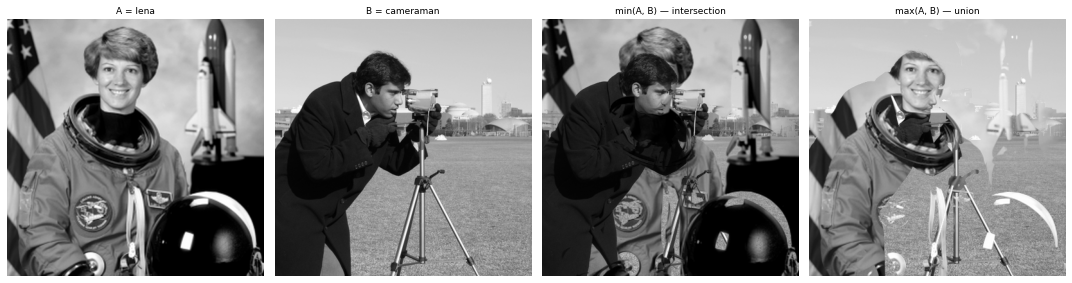

intersection mean: 80.59 | union mean: 161.16
min(A,B) + max(A,B) == A + B ? True


In [20]:
# --- grayscale ---
inter_gray = np.minimum(im1arr, im2arr)        # intersection
union_gray = np.maximum(im1arr, im2arr)        # union, for comparison

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr) in zip(ax, [("A = lena", im1arr), ("B = cameraman", im2arr),
                            ("min(A, B) — intersection", inter_gray),
                            ("max(A, B) — union", union_gray)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

print("intersection mean:", round(inter_gray.mean(), 2),
      "| union mean:", round(union_gray.mean(), 2))
print("min(A,B) + max(A,B) == A + B ?",
      np.array_equal(inter_gray.astype(int) + union_gray.astype(int),
                     im1arr.astype(int) + im2arr.astype(int)))

### All operations together

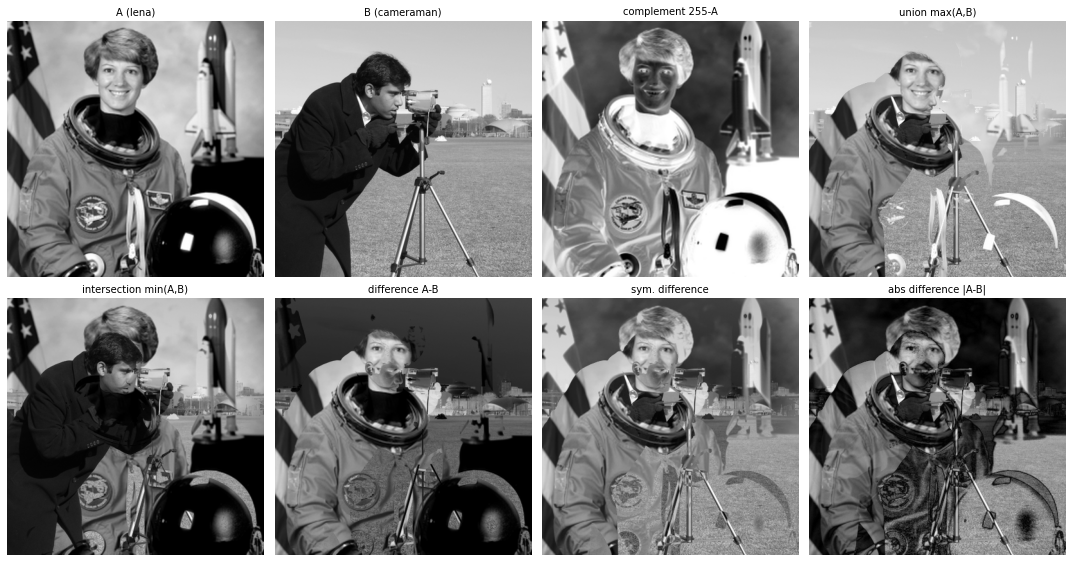

In [21]:
ops = {"A (lena)": im1arr, "B (cameraman)": im2arr,
       "complement 255-A": 255 - im1arr,
       "union max(A,B)": union_gray, "intersection min(A,B)": inter_gray,
       "difference A-B": diff_AB, "sym. difference": sym_diff,
       "abs difference |A-B|": sub_abs}

fig, ax = plt.subplots(2, 4, figsize=(15, 8))
for a, (t, arr) in zip(ax.ravel(), ops.items()):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

## Summary of results

**Sampling** reduces **spatial** resolution — the pixel grid gets coarser, fine detail disappears, edges become blocky, and storage drops with the square of the factor. **Quantization** reduces **intensity** resolution — the pixel grid is unchanged but the number of available gray levels shrinks, producing false contouring in smooth regions, clearly visible below 16 levels.

Every arithmetic and set operation reduces to element-wise NumPy work on two arrays of equal shape:

| Task | Correct expression |
|---|---|
| Addition | `cv2.add(A, B)` — never `A + B` on `uint8` |
| Subtraction | `cv2.subtract(A, B)` or `cv2.absdiff(A, B)` |
| Add constant 175 | `np.clip(A.astype(np.int16) + 175, 0, 255)` |
| Union | `np.maximum(A, B)` |
| Intersection | `np.minimum(A, B)` |
| Set difference | `np.minimum(A, 255 - B)` |
| Symmetric difference | `np.maximum(A - B, B - A)` |

The recurring trap throughout the lab is `uint8` arithmetic: it wraps modulo 256 in both directions, so `200 + 100 = 44` and `50 - 100 = 206`. Either use the saturating OpenCV functions or cast to a wider type, compute, `np.clip` to [0, 255], and cast back.
